In [1]:
from IPython.display import display, Markdown

display(Markdown("""
**Zamanidis Konstantinos 03474**

### Classification of football player's value class

The dataset includes player data from FIFA 15 to EA Sports FC 24.

Link: https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv

"""))


**Zamanidis Konstantinos 03474**

### Classification of football player's value class

The dataset includes player data from FIFA 15 to EA Sports FC 24.

Link: https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, precision_recall_fscore_support,  confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import time
import warnings
warnings.filterwarnings('ignore') 
sns.set(style="whitegrid")

df = pd.read_csv('male_players.csv', low_memory=False)
display(df.head(3))

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3


In [12]:
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

0: player_id
1: player_url
2: fifa_version
3: fifa_update
4: update_as_of
5: short_name
6: long_name
7: player_positions
8: overall
9: potential
10: value_eur
11: wage_eur
12: age
13: dob
14: height_cm
15: weight_kg
16: club_team_id
17: club_name
18: league_id
19: league_name
20: league_level
21: club_position
22: club_jersey_number
23: club_loaned_from
24: club_joined_date
25: club_contract_valid_until_year
26: nationality_id
27: nationality_name
28: nation_team_id
29: nation_position
30: nation_jersey_number
31: preferred_foot
32: weak_foot
33: skill_moves
34: international_reputation
35: work_rate
36: body_type
37: real_face
38: release_clause_eur
39: player_tags
40: player_traits
41: pace
42: shooting
43: passing
44: dribbling
45: defending
46: physic
47: attacking_crossing
48: attacking_finishing
49: attacking_heading_accuracy
50: attacking_short_passing
51: attacking_volleys
52: skill_dribbling
53: skill_curve
54: skill_fk_accuracy
55: skill_long_passing
56: skill_ball_control
57

In [13]:
selected_columns = [
    # General Info 
    'short_name',               
    'player_positions',        
    'value_eur',                # target
    'wage_eur',                 
    'age',                      
    'height_cm',                
    'weight_kg',                
    'league_level',             
    'international_reputation', 
    'preferred_foot',           
    'weak_foot',                
    'skill_moves',              
    'work_rate',                
    # Stats
    'overall',                  
    'potential',                
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 
    'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_standing_tackle', 'defending_sliding_tackle', 'defending_marking_awareness',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
    'goalkeeping_positioning', 'goalkeeping_reflexes'
]

df_clean = df[selected_columns].copy()

In [14]:
# 1.1 Cleaning
df_clean.dropna(subset=['value_eur'], inplace=True)

# Add position
df_clean['primary_pos'] = df_clean['player_positions'].apply(lambda x: x.split(',')[0].strip())

pos_mapping = {
    'GK': 0,
    'LB': 1, 'LWB': 1, 'RB': 1, 'RWB': 1, 'CB': 1, # Defenders
    'CDM': 2, 'CM': 2, 'CAM': 2, 'LM': 2, 'RM': 2, # Midfielders
    'LW': 3, 'RW': 3, 'CF': 3, 'ST': 3             # Attackers
}

# Encoding: Preferred Foot (Right=0, Left=1)
df_clean['preferred_foot'] = df_clean['preferred_foot'].map({'Right': 0, 'Left': 1})

# Encoding: Work Rate 
rate_map = {'Low': 1, 'Medium': 2, 'High': 3}
def parse_work_rate(wr):
    if pd.isna(wr): return 0
    try:
        att, deff = wr.split('/')
        return rate_map.get(att, 2) + rate_map.get(deff, 2)
    except:
        return 4
df_clean['work_rate_score'] = df_clean['work_rate'].apply(parse_work_rate)

df_clean.drop(['work_rate', 'player_positions'], axis=1, inplace=True)

# Gk skills = 0  for outfield players
gk_cols = ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 
           'goalkeeping_positioning', 'goalkeeping_reflexes']
df_clean[gk_cols] = df_clean[gk_cols].fillna(0)

# Mean Calculations
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())

# Value Classes
def create_class(value):
    if value < 2000000: return 0      # Low
    elif value <= 15000000: return 1  # Mid
    else: return 2                    # High

df_clean['Value_Category'] = df_clean['value_eur'].apply(create_class)

print(f"Final Dataset Size: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Final Dataset Size: 177868 rows, 56 columns


In [15]:
# Question 1.2
wage_stats = df_clean['wage_eur'].describe()

print("\n Wage Stats:")
print(f"   • Mean:  €{wage_stats['mean']:.2f}")
print(f"   • Std: €{wage_stats['std']:.2f}")
print(f"   • Min:     €{wage_stats['min']:.0f}")
print(f"   • Max:      €{wage_stats['max']:.0f}")


 Wage Stats:
   • Mean:  €10642.26
   • Std: €21651.29
   • Min:     €500
   • Max:      €575000


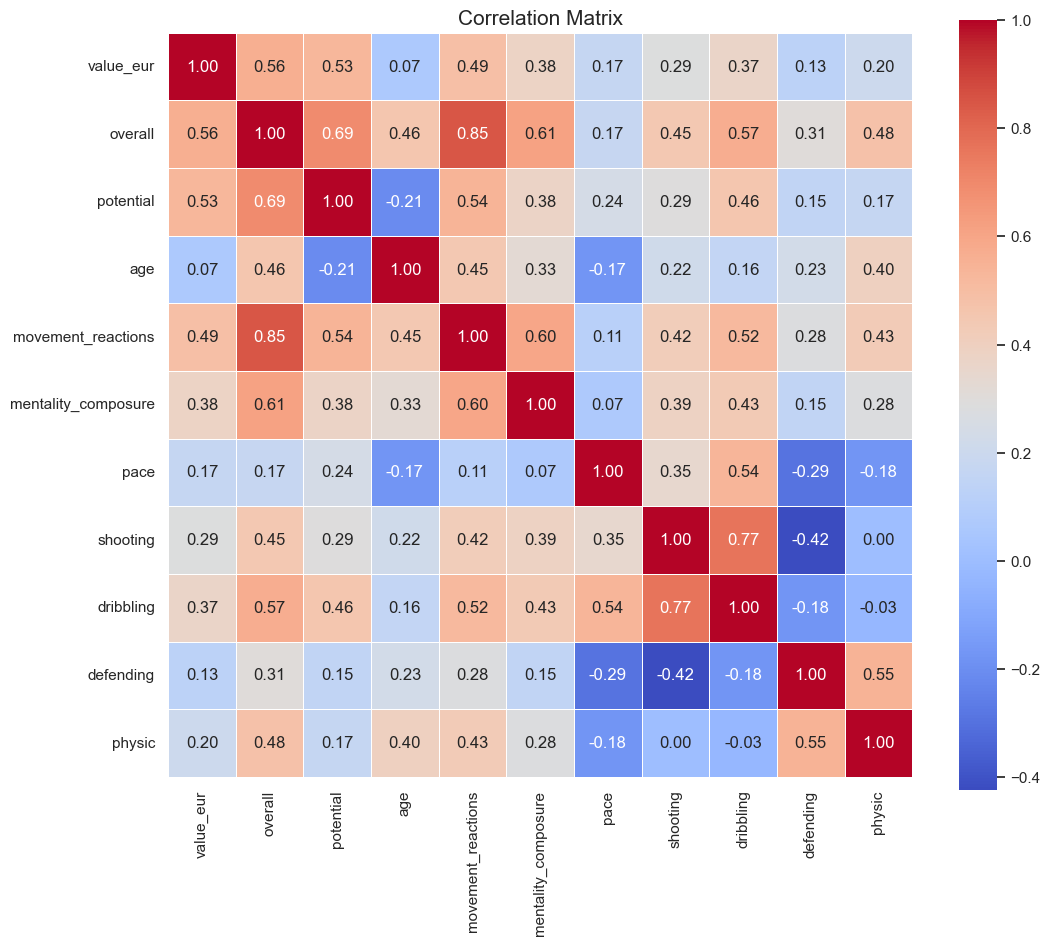

In [16]:
# Question 1.3
# We choose the following columns for heatmap
cols_for_analysis = [
    'value_eur',               
    'overall', 'potential',    
    'age',                      
    'movement_reactions',       
    'mentality_composure',      
    'pace', 'shooting', 'dribbling', 'defending', 'physic'
]

# Heatmap
plt.figure(figsize=(12, 10))

# Pearson Correlation
corr_matrix = df_clean[cols_for_analysis].corr()

sns.heatmap(corr_matrix, 
            annot=True,         
            fmt=".2f",          
            cmap='coolwarm',    
            linewidths=0.5, 
            square=True)

plt.title('Correlation Matrix', fontsize=15)
plt.show()

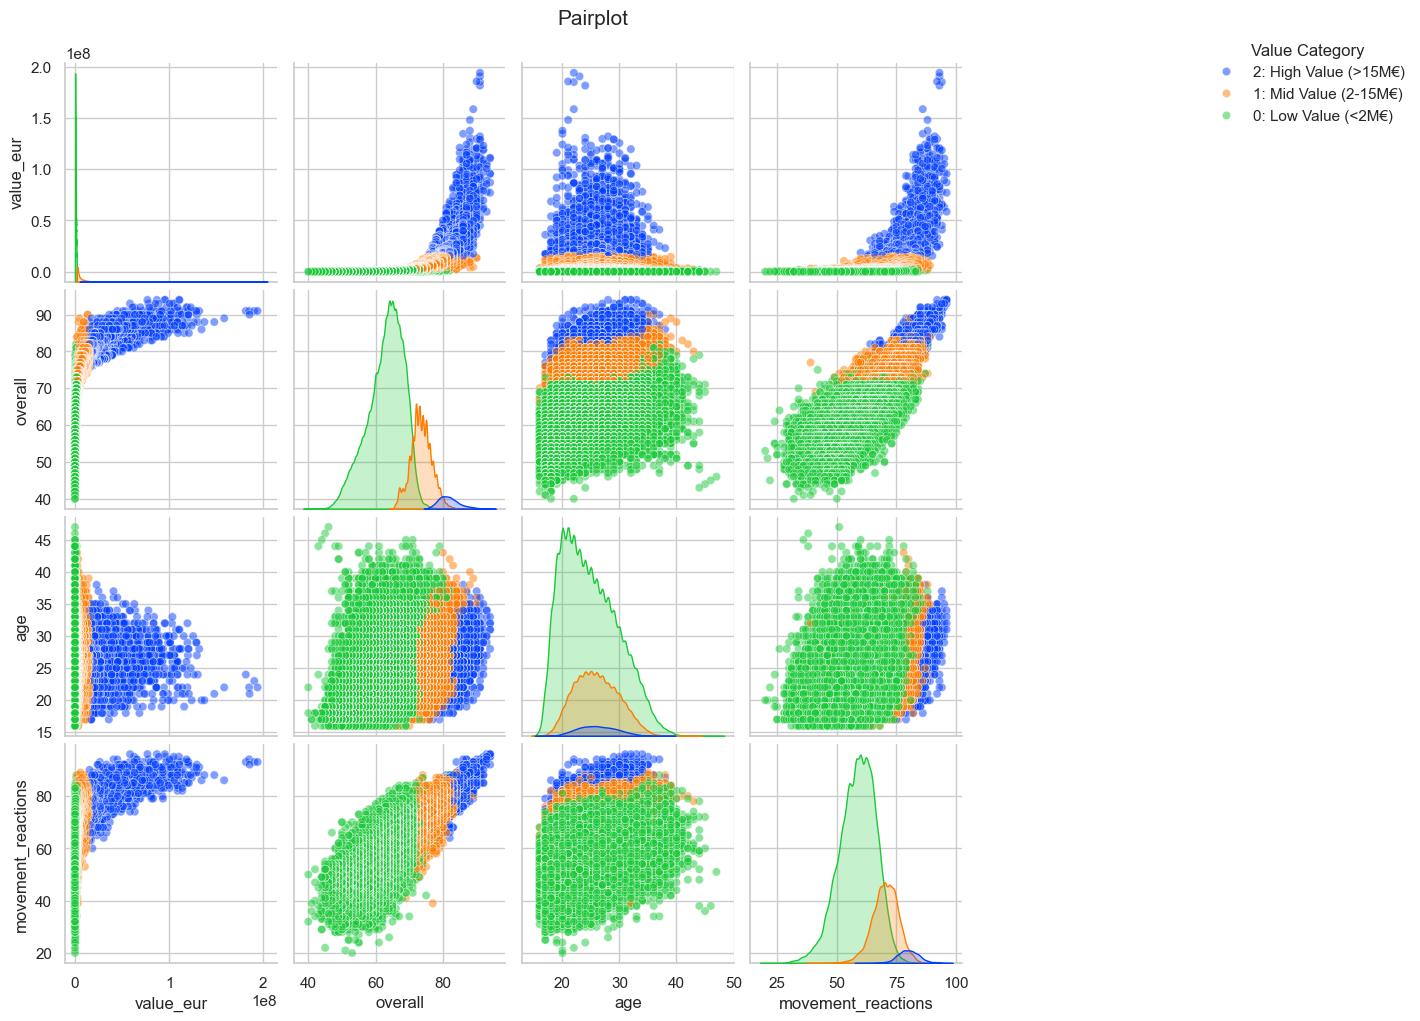

In [17]:
# We choose the following columns for pairplot
pair_cols = ['value_eur', 'overall', 'age', 'movement_reactions']

# Temporary df
plot_df = df_clean[pair_cols].copy()

label_mapping = {
    0: '0: Low Value (<2M€)',
    1: '1: Mid Value (2-15M€)',
    2: '2: High Value (>15M€)'
}
plot_df['Legend_Label'] = df_clean['Value_Category'].map(label_mapping)

# Pairplot
g = sns.pairplot(plot_df, 
                 hue='Legend_Label',       
                 palette='bright',        
                 diag_kind='kde',      
                 plot_kws={'alpha': 0.5},  
                 height=2.5)               

g.fig.suptitle('Pairplot', y=1.02, fontsize=15)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title='Value Category')
plt.show()

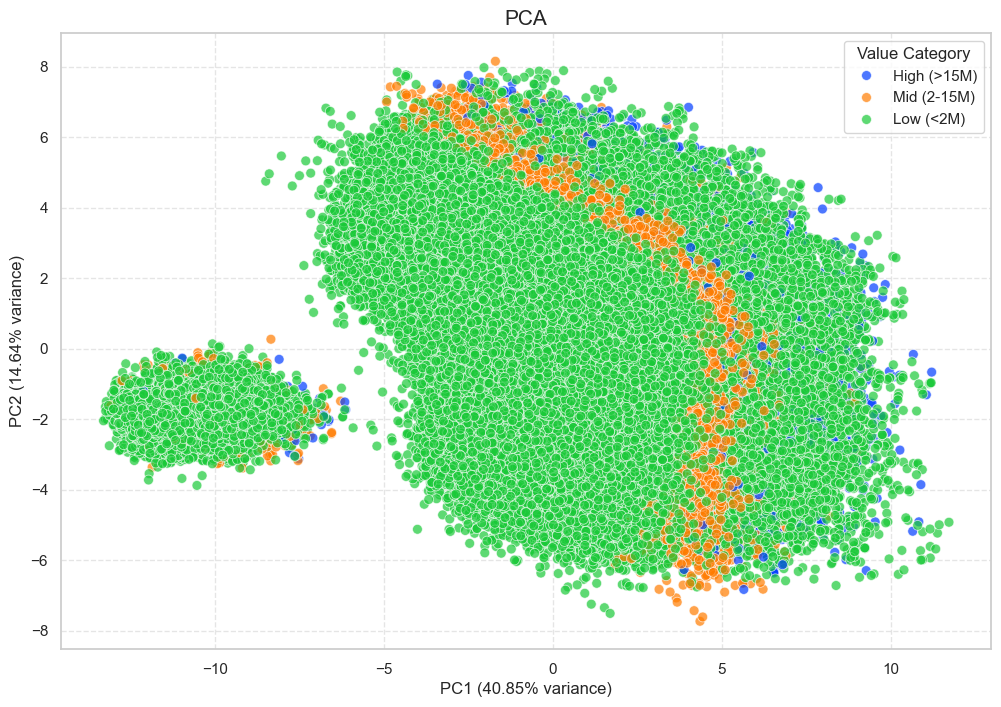


 PC1 Top features
skill_ball_control         0.210367
skill_dribbling            0.206577
attacking_short_passing    0.200184
mentality_positioning      0.194975
attacking_crossing         0.193561
Name: PC1, dtype: float64

 PC2 Top features
defending                      0.304928
defending_standing_tackle      0.295467
defending_sliding_tackle       0.294856
defending_marking_awareness    0.292760
mentality_interceptions        0.290100
Name: PC2, dtype: float64


In [18]:
# Question 1.4
cols_to_drop = ['short_name', 'value_eur', 'wage_eur', 'Value_Category', 'primary_pos']
X = df_clean.drop(columns=cols_to_drop)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

label_mapping = {0: 'Low (<2M)', 1: 'Mid (2-15M)', 2: 'High (>15M)'}
pca_df['Category'] = df_clean['Value_Category'].map(label_mapping)


# Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', 
                hue='Category', 
                palette='bright', 
                data=pca_df, 
                alpha=0.7, 
                s=50) 

plt.title('PCA', fontsize=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Value Category', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)

print("\n PC1 Top features")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\n PC2 Top features")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

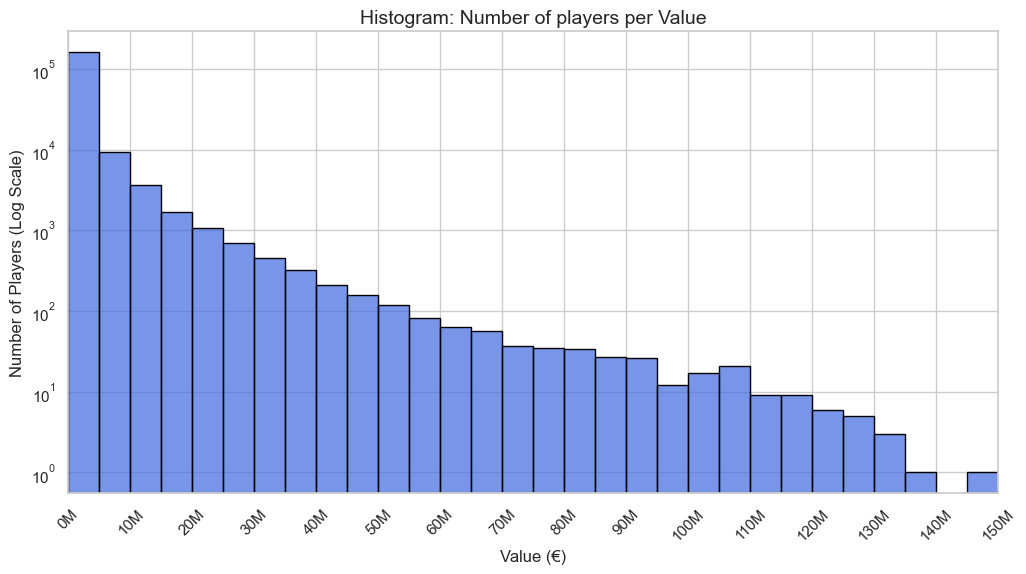

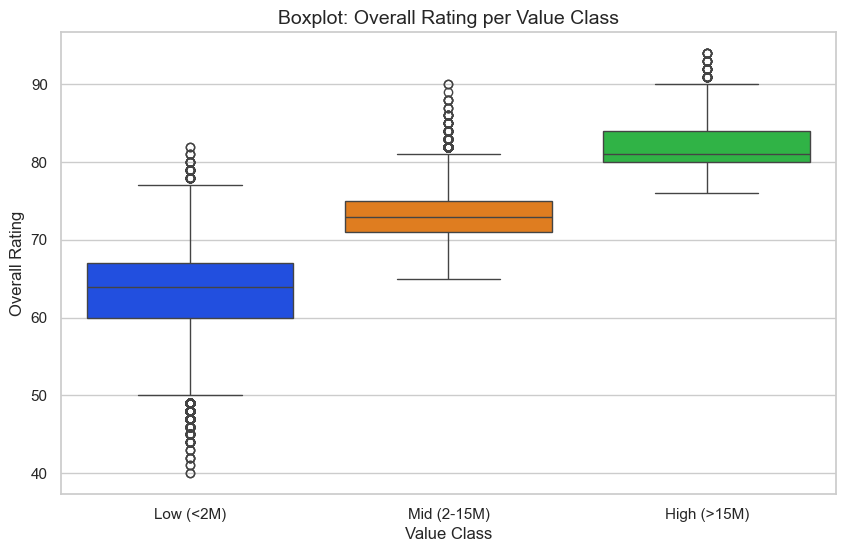

In [19]:
# Question 1.5
plt.figure(figsize=(12, 6))

# Histogram
# Bins per 5.000.000€
max_val = df_clean['value_eur'].max()
bins_5m = np.arange(0, max_val + 5000000, 5000000)
sns.histplot(df_clean['value_eur'], bins=bins_5m, color='royalblue', edgecolor='black', alpha=0.7)

# Log Scale
plt.yscale('log')

def millions_formatter(x, pos):
    return f'{x*1e-6:.0f}M'

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.xticks(np.arange(0, max_val + 10000000, 10000000), rotation=45)
plt.xlim(0, 150000000)
plt.title('Histogram: Number of players per Value', fontsize=14)
plt.xlabel('Value (€)')
plt.ylabel('Number of Players (Log Scale)')
plt.show()

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Value_Category', y='overall', data=df_clean, palette='bright')

plt.xticks([0, 1, 2], ['Low (<2M)', 'Mid (2-15M)', 'High (>15M)'])
plt.title('Boxplot: Overall Rating per Value Class', fontsize=14)
plt.xlabel('Value Class')
plt.ylabel('Overall Rating')
plt.show()

In [27]:
# Question 2.1
# Keeping only stats
cols_exclude = ['short_name', 'value_eur', 'wage_eur', 'Value_Category', 'primary_pos', 'position_group']
X_cluster = df_clean.drop(columns=cols_exclude, errors='ignore')

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means
# n=4 (GK, Defenders, Midfielders, Attackers)
print("\n1. Training K-Means...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Hierarchical Clustering
print("2. Training Hierarchical Clustering...")

# Sampling 5.000 entries
sample_size = 5000
if len(X_scaled) > sample_size:
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[indices]
else:
    X_sample = X_scaled

hierarchical = AgglomerativeClustering(n_clusters=4)
labels_hierarchical = hierarchical.fit_predict(X_sample)

# DBSCAN 
print("3. Training DBSCAN...")
dbscan = DBSCAN(eps=4.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_sample)

# Results
print("\nResults")
print(f"K-Means: {len(set(labels_kmeans))} clusters")
print(f"Hierarchical: {len(set(labels_hierarchical))} clusters")

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
print(f"DBSCAN: {n_clusters_dbscan} clusters and {n_noise} outliers")


1. Training K-Means...
2. Training Hierarchical Clustering...
3. Training DBSCAN...

Results
K-Means: 4 clusters
Hierarchical: 4 clusters
DBSCAN: 3 clusters and 576 outliers


In [34]:
# Question 2.2
# Silhouette Scores
# K-Means Score
kmeans_sample = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans_sample.fit_predict(X_sample)
score_km = silhouette_score(X_sample, labels_km)
print(f"K-Means (k=4) Score:       {score_km:.3f}")

# Hierarchical Score
hier_sample = AgglomerativeClustering(n_clusters=4)
labels_hier = hier_sample.fit_predict(X_sample)
score_hier = silhouette_score(X_sample, labels_hier)
print(f"Hierarchical (k=4) Score:  {score_hier:.3f}")

# DBSCAN Score 
dbscan_sample = DBSCAN(eps=4.0, min_samples=5)
labels_db = dbscan_sample.fit_predict(X_sample)
n_db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

if n_db_clusters > 1:
    score_db = silhouette_score(X_sample, labels_db)
    print(f"DBSCAN (eps=4) Score:      {score_db:.3f} ({n_db_clusters} clusters)")
else:
    print(f"DBSCAN Score:             No score, only 1 cluster")

K-Means (k=4) Score:       0.209
Hierarchical (k=4) Score:  0.185
DBSCAN (eps=4) Score:      0.107 (3 clusters)


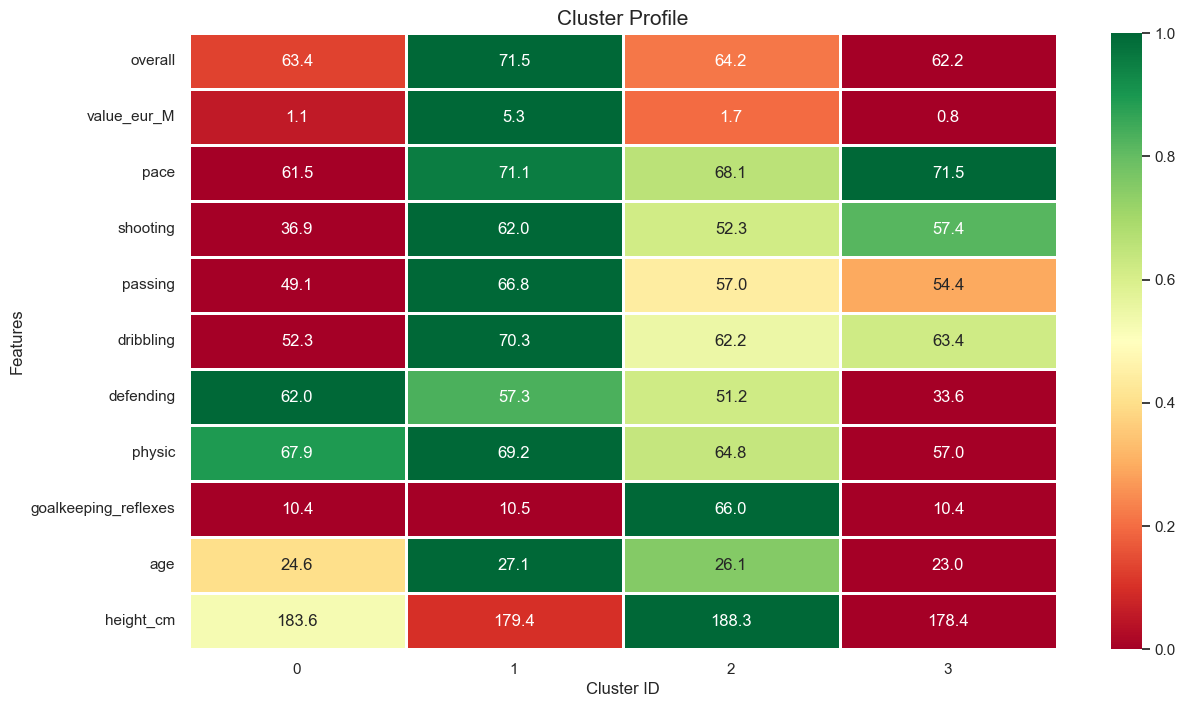


Players per Cluster
Cluster
0    51777
1    55122
2    19742
3    51227
Name: count, dtype: int64


In [38]:
# Question 2.3
df_clean['Cluster'] = labels_kmeans
analysis_df = df_clean.copy()

# Value to millions
analysis_df['value_eur_M'] = analysis_df['value_eur'] / 1_000_000
analysis_df = analysis_df.drop(columns=['value_eur'])

cols_to_analyze = [
    'overall', 'value_eur_M',      
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'goalkeeping_reflexes',
    'age', 'height_cm'
]

# Mean per cluster
cluster_means = analysis_df.groupby('Cluster')[cols_to_analyze].mean()
normalized_means = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Visualization
plt.figure(figsize=(14, 8))


sns.heatmap(normalized_means.T, 
            annot=cluster_means.T,  
            fmt='.1f',              
            cmap='RdYlGn',          
            linewidths=1)

plt.title('Cluster Profile', fontsize=15)
plt.xlabel('Cluster ID')
plt.ylabel('Features')
plt.show()

print("\nPlayers per Cluster")
print(df_clean['Cluster'].value_counts().sort_index())

In [45]:
# Question 3.1
model_names = []
accuracies = []
training_times = []
predictions = {} 

cols_exclude = ['short_name', 'value_eur', 'wage_eur', 'Value_Category', 
                'primary_pos', 'position_group', 'Cluster', 'value_eur_M']

X = df_clean.drop(columns=cols_exclude, errors='ignore')
y = df_clean['Value_Category']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Decision Tree
print("\n1. Training Decision Tree...")
start_time = time.time()

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_time = time.time() - start_time
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"   Training completed in {dt_time:.2f} sec")
print(f"   Accuracy: {dt_acc:.2%}")

# Saving
model_names.append('Decision Tree')
accuracies.append(dt_acc)
training_times.append(dt_time)
predictions['Decision Tree'] = dt_pred


# SVM
print("\n2. Training SVM...")
start_time = time.time()

svm_sample_size = 20000
indices_svm = np.random.choice(len(X_train), svm_sample_size, replace=False)
X_train_svm = X_train[indices_svm]
y_train_svm = y_train.iloc[indices_svm] 


svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

svm_time = time.time() - start_time
svm_pred = svm_model.predict(X_test) 
svm_acc = accuracy_score(y_test, svm_pred)

print(f"   Training completed in {svm_time:.2f} sec (Sample size: {svm_sample_size} players)")
print(f"   Accuracy: {svm_acc:.2%}")

# Saving
model_names.append('SVM')
accuracies.append(svm_acc)
training_times.append(svm_time)
predictions['SVM'] = svm_pred


# Neural Network
print("\n3. Training Neural Network (MLP)...")
start_time = time.time()

mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), 
                          activation='relu', 
                          solver='adam', 
                          max_iter=200, 
                          random_state=42,
                          early_stopping=True) 

mlp_model.fit(X_train, y_train)

mlp_time = time.time() - start_time
mlp_pred = mlp_model.predict(X_test)
mlp_acc = accuracy_score(y_test, mlp_pred)

print(f"   Training completed in {mlp_time:.2f} sec")
print(f"   Accuracy: {mlp_acc:.2%}")

# Saving
model_names.append('Neural Network')
accuracies.append(mlp_acc)
training_times.append(mlp_time)
predictions['Neural Network'] = mlp_pred


1. Training Decision Tree...
   Training completed in 1.66 sec
   Accuracy: 96.31%

2. Training SVM...
   Training completed in 2.94 sec (Sample size: 20000 players)
   Accuracy: 94.81%

3. Training Neural Network (MLP)...
   Training completed in 28.79 sec
   Accuracy: 96.12%



==================== Decision Tree ====================
              precision    recall  f1-score   support

         Low       0.98      0.98      0.98     27194
         Mid       0.90      0.92      0.91      7401
        High       0.84      0.88      0.86       979

    accuracy                           0.96     35574
   macro avg       0.91      0.93      0.92     35574
weighted avg       0.96      0.96      0.96     35574


==================== SVM ====================
              precision    recall  f1-score   support

         Low       0.97      0.98      0.97     27194
         Mid       0.88      0.87      0.87      7401
        High       0.92      0.74      0.82       979

    accuracy                           0.95     35574
   macro avg       0.92      0.86      0.89     35574
weighted avg       0.95      0.95      0.95     35574


==================== Neural Network ====================
              precision    recall  f1-score   support

         Low       0.

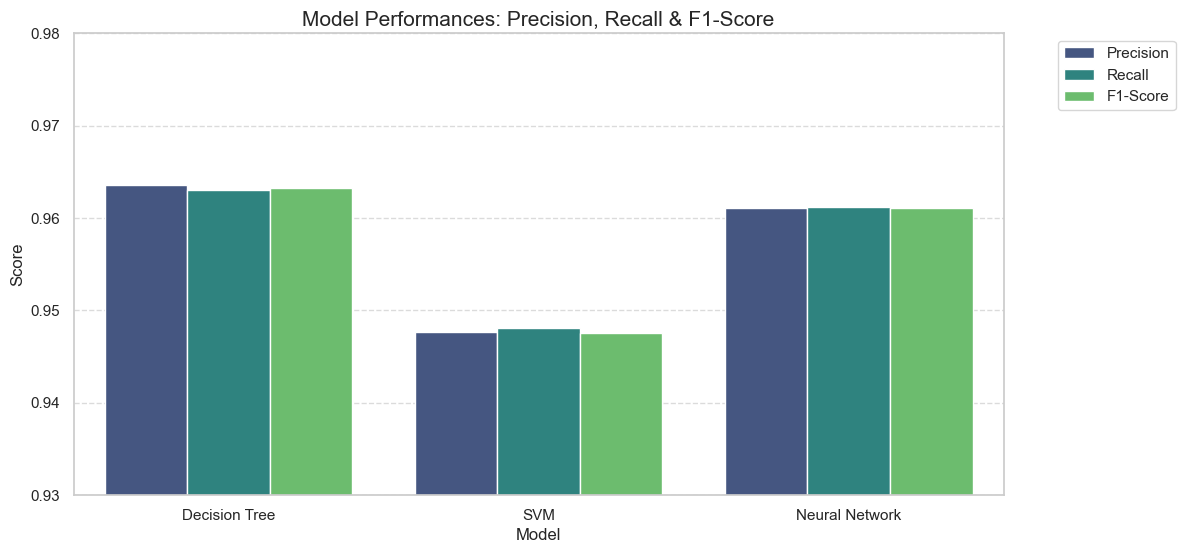

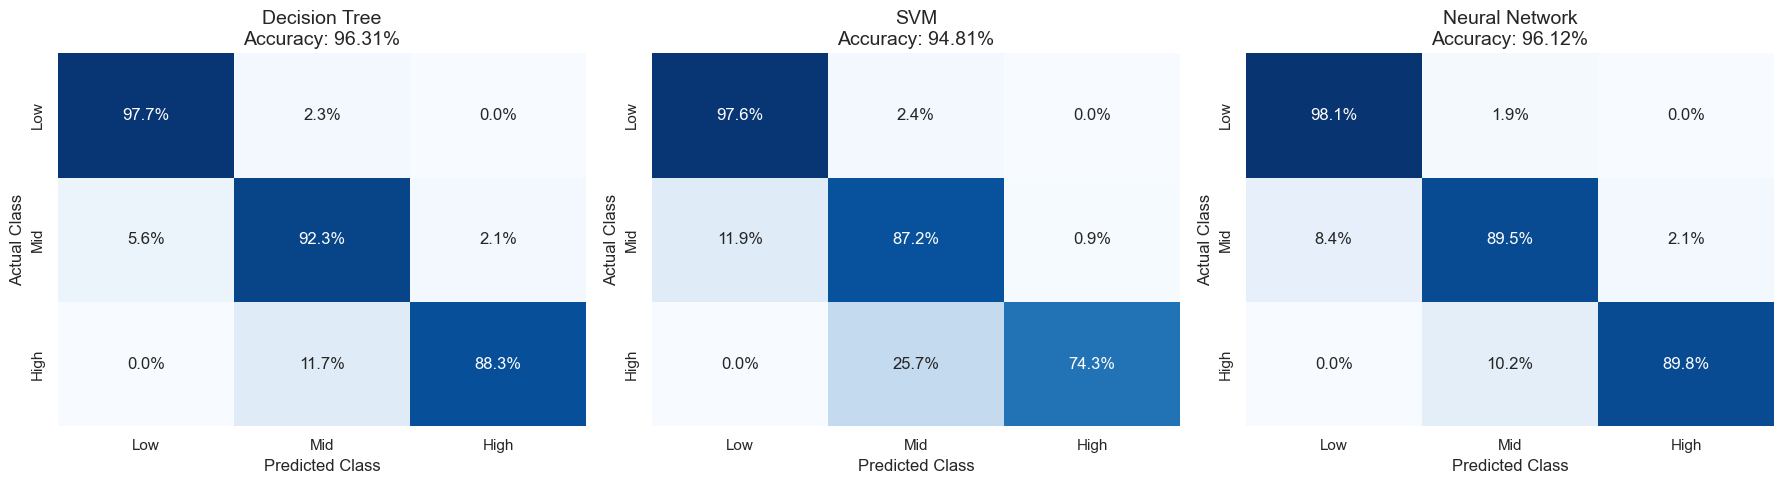

In [54]:
# Question 3.2
metrics_summary = []
for model_name in model_names:
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_test, predictions[model_name], target_names=['Low', 'Mid', 'High']))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions[model_name], average='weighted')
    metrics_summary.append({
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="viridis")
plt.ylim(0.93, 0.98) 
plt.title('Model Performances: Precision, Recall & F1-Score', fontsize=15)
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Low', 'Mid', 'High']

for i, model in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[model], normalize='true')
    sns.heatmap(cm, 
                annot=True, 
                fmt='.1%',      
                cmap='Blues', 
                cbar=False, 
                ax=axes[i],
                xticklabels=class_labels, 
                yticklabels=class_labels,
                vmin=0, vmax=1)
    
    axes[i].set_title(f'{model}\nAccuracy: {accuracies[i]:.2%}', fontsize=14)
    axes[i].set_xlabel('Predicted Class')
    axes[i].set_ylabel('Actual Class')

plt.tight_layout()
plt.show()